In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Simulation 1

In [2]:
# read simulation 1 data
df = pd.read_csv("../data/simulations/simulation1_all_WISER.csv")
mapping_dict = {"gumbel": "Gumbel", "inverse": "Inverse", "redgreen": "Red-Green", "pf": "Permute-and-Flip"}
df['watermark_type'] = df['watermark_type'].map(mapping_dict)
df.head()


,model_name,iou,iou_median,iou_lower,iou_upper,precision,recall,f1,rand_index,rand_index_median,...,time_lower,time_upper,khat_over,khat_under,khat_exact,vocab_size,output_tokens,watermark_type,seed,ar_coeff
0,simulation 1,0.968968,0.97600,0.915952,0.996016,0.986250,1.0000,0.993077,0.971460,0.979808,...,0.000047,0.000198,0.0275,0.0000,0.9725,1000,500,Gumbel,1234,0.1
1,simulation 1,0.898420,0.91573,0.733318,0.988048,0.832458,1.0000,0.908570,0.911402,0.924878,...,0.000047,0.000209,0.3215,0.0000,0.6785,1000,500,Inverse,1234,0.1
2,simulation 1,0.245201,0.28800,0.000000,0.720000,0.522083,0.5885,0.553306,0.590483,0.622758,...,0.000025,0.000213,0.1305,0.4115,0.4580,1000,500,Red-Green,1234,0.1
3,simulation 1,0.941182,0.96000,0.808000,0.988000,0.787000,1.0000,0.880806,0.922681,0.957900,...,0.000048,0.000226,0.4195,0.0000,0.5805,1000,500,Permute-and-Flip,1234,0.1
4,simulation 1,0.980534,0.98800,0.932000,0.996016,0.999500,1.0000,0.999750,0.983396,0.990437,...,0.000047,0.000187,0.0010,0.0000,0.9990,1000,500,Gumbel,1234,0.2


<>:37: SyntaxWarning: invalid escape sequence '\p'
<>:37: SyntaxWarning: invalid escape sequence '\p'
/var/folders/v9/p596rfjn6f5cxry5bh_b_0cw0000gn/T/ipykernel_1761/3478156900.py:37: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel(f"$\phi$", fontsize=14, labelpad=10)


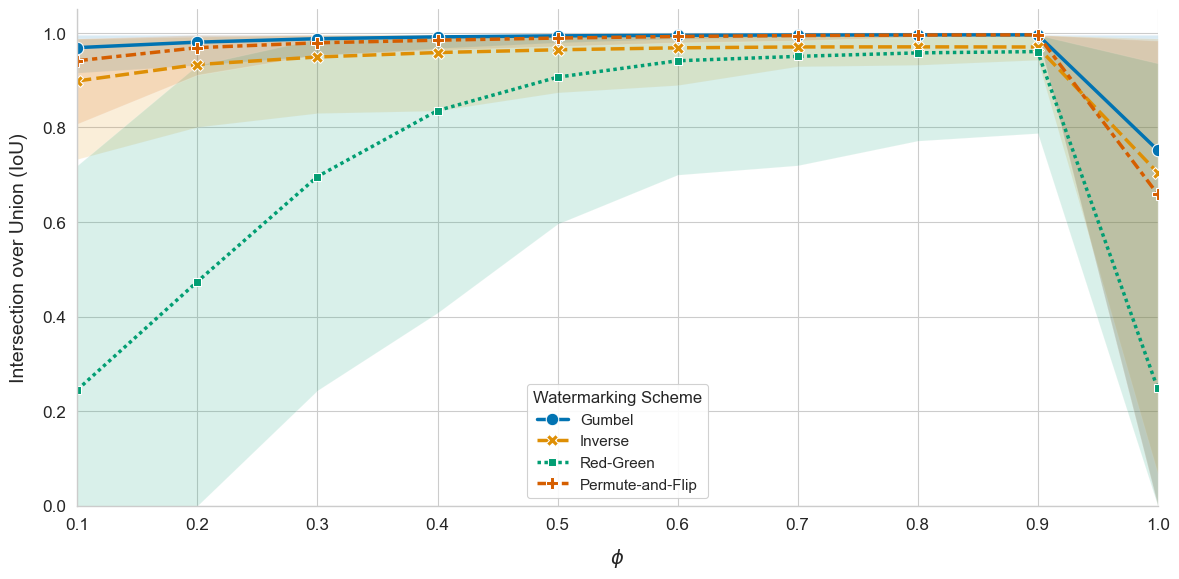

In [5]:
plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)

# color friendly pallete
unique_methods = df['watermark_type'].unique()
palette = sns.color_palette("colorblind", n_colors=len(unique_methods))
method_colors = dict(zip(unique_methods, palette))

# create confidence bands
for method in unique_methods:
    subset = df[df['watermark_type'] == method].sort_values('ar_coeff')
    plt.fill_between(
        subset['ar_coeff'],
        subset['iou_lower'],
        subset['iou_upper'],
        color=method_colors[method],
        alpha=0.15, # Transparency for the bands
        edgecolor=None # No border on the band
    )

# main lineplot
sns.lineplot(
    data=df,
    x='ar_coeff',
    y='iou',
    hue='watermark_type',
    style='watermark_type',
    palette=method_colors,
    markers=True, 
    dashes=True,
    linewidth=2.5,
    markersize=9
)

# Labeling
plt.xlabel(f"$\phi$", fontsize=14, labelpad=10)
plt.ylabel("Intersection over Union (IoU)", fontsize=14, labelpad=10)

# Axis customization
plt.ylim(0, 1.05)
plt.xlim(df['ar_coeff'].min(), df['ar_coeff'].max())

# Customize the legend
# moving it outside or to a "best" location
plt.legend(title='Watermarking Scheme', title_fontsize=12, fontsize=11, loc='best', frameon=True, framealpha=0.9)

# Remove top and right spines for a cleaner "academic" look
sns.despine()
plt.tight_layout()
plt.show()

## Simulation 2 (Delta + n)

In [25]:
# read simulation 3 data
df = pd.read_csv("../data/simulations/simulation2_all_WISER.csv")
df['delta'] = df['delta'].astype(str)
df

,model_name,iou,iou_median,iou_lower,iou_upper,precision,recall,f1,rand_index,rand_index_median,...,time_lower,time_upper,khat_over,khat_under,khat_exact,vocab_size,output_tokens,watermark_type,seed,delta
0,simulation 2,0.002036,0.000000,0.000000,0.000000,0.003000,0.0030,0.003000,0.329420,0.327877,...,0.000011,0.000079,0.0000,0.9970,0.0030,1000,64,partial,1234,1.5
1,simulation 2,0.012216,0.000000,0.000000,0.000000,0.019000,0.0190,0.019000,0.337242,0.327877,...,0.000011,0.000074,0.0000,0.9810,0.0190,1000,64,partial,1234,2.0
2,simulation 2,0.050372,0.000000,0.000000,0.827730,0.065500,0.0655,0.065500,0.364093,0.327877,...,0.000012,0.000100,0.0000,0.9345,0.0655,1000,64,partial,1234,2.5
3,simulation 2,0.163104,0.000000,0.000000,0.960000,0.202000,0.2020,0.202000,0.442990,0.327877,...,0.000012,0.000094,0.0000,0.7980,0.2020,1000,64,partial,1234,3.0
4,simulation 2,0.331886,0.000000,0.000000,0.961538,0.398000,0.3980,0.398000,0.559462,0.327877,...,0.000013,0.000129,0.0000,0.6020,0.3980,1000,64,partial,1234,3.5
5,simulation 2,0.003871,0.000000,0.000000,0.000000,0.007500,0.0075,0.007500,0.338125,0.334523,...,0.000012,0.000075,0.0000,0.9920,0.0080,1000,128,partial,1234,1.5
6,simulation 2,0.033433,0.000000,0.000000,0.627451,0.055750,0.0560,0.055875,0.361841,0.334523,...,0.000013,0.000079,0.0005,0.9435,0.0560,1000,128,partial,1234,2.0
7,simulation 2,0.126165,0.000000,0.000000,0.843137,0.196250,0.1970,0.196624,0.433088,0.334523,...,0.000014,0.000097,0.0015,0.8025,0.1960,1000,128,partial,1234,2.5
8,simulation 2,0.332584,0.000000,0.000000,0.941176,0.463750,0.4670,0.465369,0.580998,0.334523,...,0.000016,0.000123,0.0065,0.5330,0.4605,1000,128,partial,1234,3.0
9,simulation 2,0.606815,0.720305,0.000000,0.980392,0.765750,0.7780,0.771826,0.765780,0.855684,...,0.000019,0.000133,0.0245,0.2220,0.7535,1000,128,partial,1234,3.5


<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:43: SyntaxWarning: invalid escape sequence '\d'
/var/folders/v9/p596rfjn6f5cxry5bh_b_0cw0000gn/T/ipykernel_1761/183299266.py:43: SyntaxWarning: invalid escape sequence '\d'
  plt.legend(title=f"$\delta$", title_fontsize=12, fontsize=11, loc='best', frameon=True, framealpha=0.9)


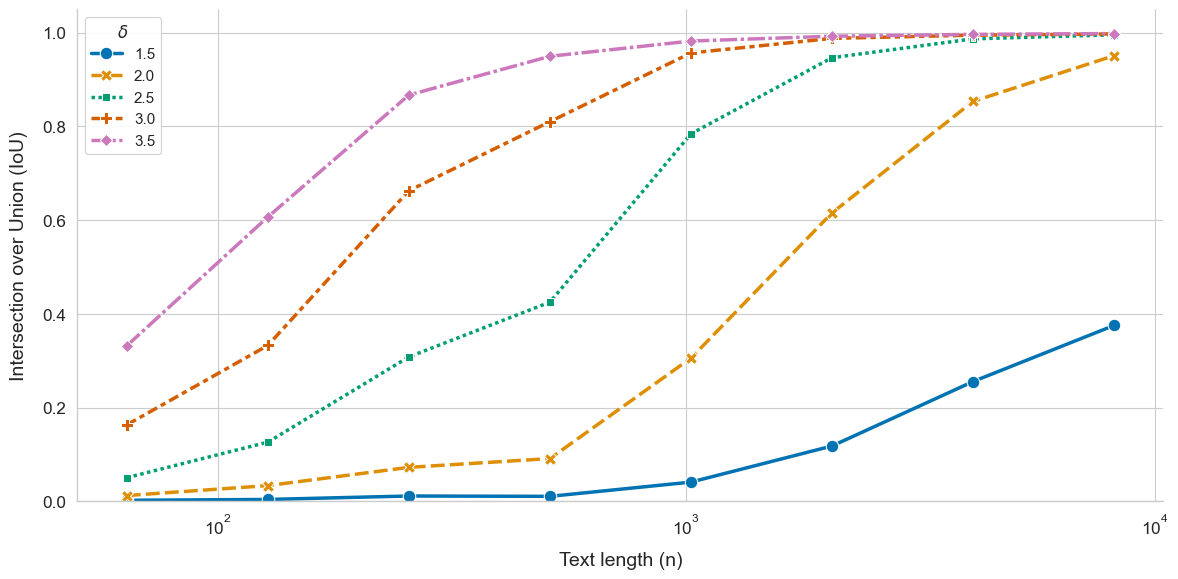

In [29]:
plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)

# color friendly pallete
unique_deltas = df['delta'].unique()
palette = sns.color_palette("colorblind", n_colors=len(unique_deltas))
delta_colors = dict(zip(unique_deltas, palette))

# # create confidence bands
# for delta in delta_colors:
#     subset = df[df['delta'] == delta].sort_values('output_tokens')
#     plt.fill_between(
#         subset['output_tokens'],
#         subset['iou_lower'],
#         subset['iou_upper'],
#         color=delta_colors[delta],
#         alpha=0.15, # Transparency for the bands
#         edgecolor=None # No border on the band
#     )

# main lineplot
sns.lineplot(
    data=df,
    x='output_tokens',
    y='iou',
    hue='delta',
    style='delta',
    palette=delta_colors,
    markers=True, 
    dashes=True,
    linewidth=2.5,
    markersize=9
)

# Labeling and axis
plt.xlabel(f"Text length (n)", fontsize=14, labelpad=10)
plt.ylabel("Intersection over Union (IoU)", fontsize=14, labelpad=10)
plt.ylim(0, 1.05)
plt.xscale('log')

# Customize the legend
# moving it outside or to a "best" location
plt.legend(title=f"$\delta$", title_fontsize=12, fontsize=11, loc='best', frameon=True, framealpha=0.9)

# Remove top and right spines for a cleaner "academic" look
sns.despine()
plt.tight_layout()
plt.show()

## Simulation 2B

In [53]:
# read simulation 3 data
df = pd.read_csv("../data/simulations/simulation2B_all_WISER.csv")
df = df.loc[df['d'] <= 3]
df

,model_name,iou,iou_median,iou_lower,iou_upper,precision,recall,f1,rand_index,rand_index_median,...,time_lower,time_upper,khat_over,khat_under,khat_exact,kdiff,vocab_size,output_tokens,seed,d
0,simulation 2B,0.002837,0.000000,0.000000,0.000000,0.004000,0.0040,0.004000,0.330060,0.327877,...,0.000011,0.000060,0.0000,0.9955,0.0045,0.997747,1000,64,1234,0.5
1,simulation 2B,0.163046,0.000000,0.000000,0.960000,0.192500,0.1925,0.192500,0.441207,0.327877,...,0.000012,0.000107,0.0000,0.8070,0.1930,0.898332,1000,64,1234,1.0
2,simulation 2B,0.738418,0.892857,0.000000,1.000000,0.825250,0.8255,0.825375,0.833571,0.937500,...,0.000017,0.000120,0.0005,0.1745,0.8250,0.418330,1000,64,1234,1.5
3,simulation 2B,0.910077,0.925926,0.714286,1.000000,0.996250,0.9965,0.996375,0.947765,0.957341,...,0.000029,0.000130,0.0005,0.0035,0.9960,0.063246,1000,64,1234,2.0
4,simulation 2B,0.925277,0.960000,0.735294,1.000000,0.999750,1.0000,0.999875,0.957061,0.978175,...,0.000029,0.000133,0.0005,0.0000,0.9995,0.022361,1000,64,1234,2.5
5,simulation 2B,0.932954,0.960000,0.757576,1.000000,1.000000,1.0000,1.000000,0.961654,0.978175,...,0.000030,0.000137,0.0000,0.0000,1.0000,0.000000,1000,64,1234,3.0
10,simulation 2B,0.004548,0.000000,0.000000,0.000000,0.007500,0.0075,0.007500,0.338195,0.334523,...,0.000011,0.000073,0.0000,0.9925,0.0075,0.996243,1000,128,1234,0.5
11,simulation 2B,0.426391,0.607843,0.000000,0.961538,0.555500,0.5590,0.557245,0.642238,0.815945,...,0.000015,0.000140,0.0070,0.4410,0.5520,0.669328,1000,128,1234,1.0
12,simulation 2B,0.916076,0.944444,0.666667,1.000000,0.990250,0.9950,0.992619,0.953202,0.967889,...,0.000030,0.000140,0.0095,0.0050,0.9855,0.120416,1000,128,1234,1.5
13,simulation 2B,0.955987,0.980392,0.847253,1.000000,1.000000,1.0000,1.000000,0.974708,0.989050,...,0.000031,0.000153,0.0000,0.0000,1.0000,0.000000,1000,128,1234,2.0


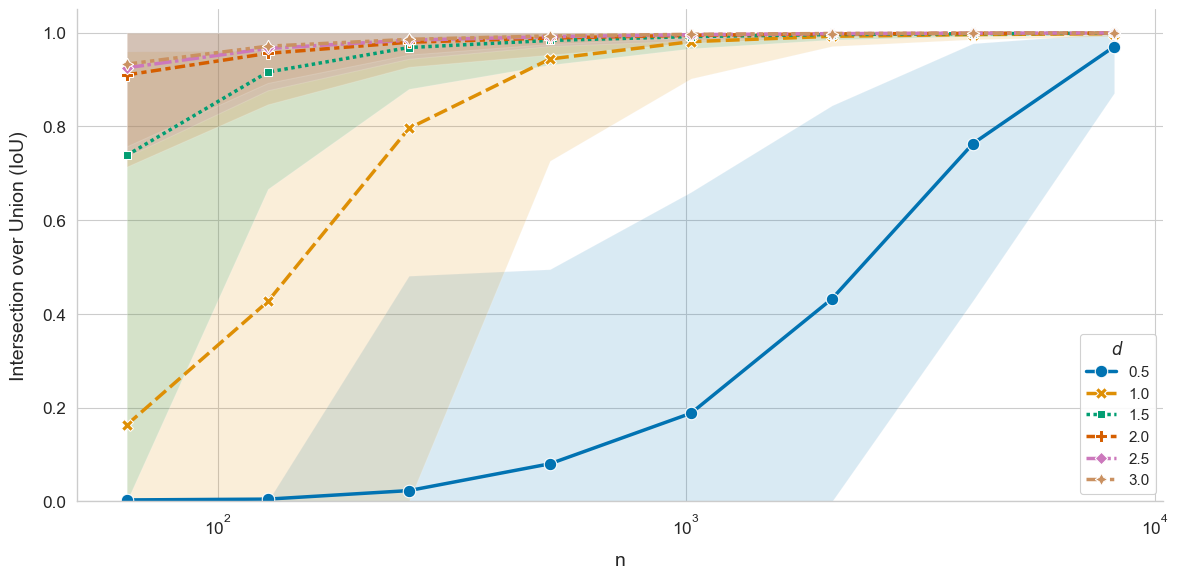

In [55]:
plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)

x_col = "output_tokens"
group_col = "d"
df[group_col] = df[group_col].astype(str)

# color friendly pallete
unique_deltas = df[group_col].unique()
palette = sns.color_palette("colorblind", n_colors=len(unique_deltas))
delta_colors = dict(zip(unique_deltas, palette))

# create confidence bands
for delta in delta_colors:
    subset = df[df[group_col] == delta].sort_values(x_col)
    plt.fill_between(
        subset[x_col],
        subset['iou_lower'],
        subset['iou_upper'],
        color=delta_colors[delta],
        alpha=0.15, # Transparency for the bands
        edgecolor=None # No border on the band
    )

# main lineplot
sns.lineplot(
    data=df,
    x=x_col,
    y='iou',
    hue=group_col,
    style=group_col,
    palette=delta_colors,
    markers=True, 
    dashes=True,
    linewidth=2.5,
    markersize=9
)

# Labeling and axis
plt.xlabel(f"n", fontsize=14, labelpad=10)
plt.ylabel("Intersection over Union (IoU)", fontsize=14, labelpad=10)
plt.ylim(0, 1.05)
plt.xscale('log')

# Customize the legend
# moving it outside or to a "best" location
plt.legend(title=f"$d$", title_fontsize=12, fontsize=11, loc='best', frameon=True, framealpha=0.9)

# Remove top and right spines for a cleaner "academic" look
sns.despine()
plt.tight_layout()
plt.show()

## Simulation 3 (Gap)

In [61]:
# read simulation 3 data
df = pd.read_csv("../data/simulations/simulation3_all_WISER.csv")

print(df.columns)
df.head()

Index(['model_name', 'iou', 'iou_median', 'iou_lower', 'iou_upper',
       'precision', 'recall', 'f1', 'rand_index', 'rand_index_median',
       'rand_index_lower', 'rand_index_upper', 'modified_rand_index',
       'modified_rand_index_median', 'modified_rand_index_lower',
       'modified_rand_index_upper', 'time', 'time_lower', 'time_upper',
       'khat_over', 'khat_under', 'khat_exact', 'kdiff', 'vocab_size',
       'output_tokens', 'watermark_type', 'seed', 'gap', 'gap_prop'],
      dtype='object')


,model_name,iou,iou_median,iou_lower,iou_upper,precision,recall,f1,rand_index,rand_index_median,...,khat_over,khat_under,khat_exact,kdiff,vocab_size,output_tokens,watermark_type,seed,gap,gap_prop
0,simulation 3,0.886894,0.932099,0.593387,0.968153,1.000000,0.411000,0.582566,0.931610,0.931132,...,0.0,0.9960,0.0040,1.819066,1000,512,gumbel,1234,2,0.10
1,simulation 3,0.855668,0.909909,0.576923,0.949686,1.000000,0.468667,0.638221,0.933974,0.928747,...,0.0,0.9905,0.0095,1.673619,1000,512,gumbel,1234,3,0.15
2,simulation 3,0.855668,0.909909,0.576923,0.949686,1.000000,0.468667,0.638221,0.933974,0.928747,...,0.0,0.9905,0.0095,1.673619,1000,512,gumbel,1234,3,0.20
3,simulation 3,0.841338,0.883436,0.575949,0.932515,1.000000,0.549167,0.708983,0.942272,0.947778,...,0.0,0.9465,0.0535,1.471224,1000,512,gumbel,1234,5,0.25
4,simulation 3,0.855457,0.893934,0.598765,0.921212,0.999833,0.569167,0.725394,0.945513,0.958002,...,0.0,0.9095,0.0905,1.434225,1000,512,gumbel,1234,6,0.30


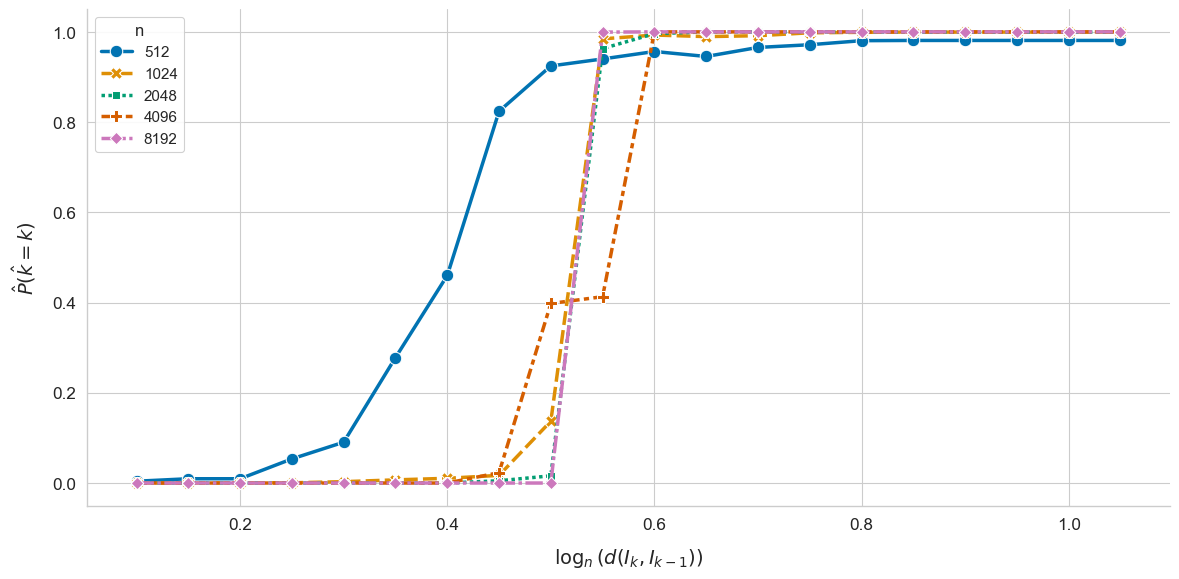

In [62]:
plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)

x_col = "gap_prop"
group_col = "output_tokens"
df[group_col] = df[group_col].astype(str)

# color friendly pallete
unique_methods = df[group_col].unique()
palette = sns.color_palette("colorblind", n_colors=len(unique_methods))
method_colors = dict(zip(unique_methods, palette))


# main lineplot
sns.lineplot(
    data=df,
    x=x_col,
    y='khat_exact',
    hue=group_col,
    style=group_col,
    palette=method_colors,
    markers=True, 
    dashes=True,
    linewidth=2.5,
    markersize=9
)

# labeling
# plt.ylim(0, 1.05)
plt.xlabel(r"$\log_{n}(d(I_k, I_{k-1}))$", fontsize=14, labelpad=10)
plt.ylabel(r"$\hat{P}(\hat{k} = k)$", fontsize=14, labelpad=10)
plt.legend(title="n", title_fontsize=12, fontsize=11, loc='best', frameon=True, framealpha=0.9)

sns.despine()
plt.tight_layout()
plt.show()